In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv(r"C:\Projects\Training\Week2\dataset\data.csv")   # change path if needed

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nTarget distribution:\n", df['diagnosis'].value_counts())
print("\nMissing values:\n", df.isnull().sum())
df.head()

Shape: (569, 33)

Columns:
 ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']

Target distribution:
 diagnosis
B    357
M    212
Name: count, dtype: int64

Missing values:
 id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mea

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [8]:
print(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [7]:
print(df.describe())

                 id  radius_mean  texture_mean  perimeter_mean    area_mean  \
count  5.690000e+02   569.000000    569.000000      569.000000   569.000000   
mean   3.037183e+07    14.127292     19.289649       91.969033   654.889104   
std    1.250206e+08     3.524049      4.301036       24.298981   351.914129   
min    8.670000e+03     6.981000      9.710000       43.790000   143.500000   
25%    8.692180e+05    11.700000     16.170000       75.170000   420.300000   
50%    9.060240e+05    13.370000     18.840000       86.240000   551.100000   
75%    8.813129e+06    15.780000     21.800000      104.100000   782.700000   
max    9.113205e+08    28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813     

In [9]:
print(df.shape)

(569, 33)


In [10]:
# 1. Drop unnecessary columns
df = df.drop(['id', 'Unnamed: 32'], axis=1, errors='ignore')

# 2. Convert target to binary (M = 1 Malignant, B = 0 Benign)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# 3. Check again
print("Shape after cleaning:", df.shape)
print("\nTarget distribution:\n", df['diagnosis'].value_counts())
print("\nAny missing values left?\n", df.isnull().sum().sum())

Shape after cleaning: (569, 31)

Target distribution:
 diagnosis
0    357
1    212
Name: count, dtype: int64

Any missing values left?
 0


In [11]:
# Separate features and target
X = df.drop('diagnosis', axis=1)
y = df['diagnosis'].values.reshape(-1, 1)   # make it 2D column vector

print("X shape:", X.shape)
print("y shape:", y.shape)

# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nTrain shapes -> X:", X_train.shape, "y:", y_train.shape)
print("Test shapes  -> X:", X_test.shape, "y:", y_test.shape)

X shape: (569, 30)
y shape: (569, 1)

Train shapes -> X: (455, 30) y: (455, 1)
Test shapes  -> X: (114, 30) y: (114, 1)


In [12]:
# Convert to numpy arrays
X_train = X_train.values
X_test = X_test.values
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

# Feature Scaling (Z-score normalization) - ONLY on train, then apply to test
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)

# Avoid division by zero (rare but safe)
std[std == 0] = 1

X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std

print("Scaling done!")
print("X_train_scaled shape:", X_train_scaled.shape)
print("Mean of scaled train (should be near 0):", np.mean(X_train_scaled, axis=0)[:5])  # first 5 features
print("Std of scaled train (should be near 1):", np.std(X_train_scaled, axis=0)[:5])

Scaling done!
X_train_scaled shape: (455, 30)
Mean of scaled train (should be near 0): [-3.16230558e-16 -3.51367287e-17 -1.13218348e-16  3.66983611e-16
 -2.38148939e-16]
Std of scaled train (should be near 1): [1. 1. 1. 1. 1.]


In [15]:
# 1. Sigmoid Function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 2. Logistic Cost Function (Log Loss) - Exactly as Andrew Ng taught
def cost_function(X, y, theta):
    m = X.shape[0]
    z = X @ theta
    h = sigmoid(z)
    
    # Add small epsilon to avoid log(0)
    epsilon = 1e-8
    h = np.clip(h, epsilon, 1 - epsilon)
    
    cost = (-1/m) * np.sum(y * np.log(h) + (1 - y) * np.log(1 - h))
    return cost

# 3. Gradient for Logistic Regression
def compute_gradient(X, y, theta):
    m = X.shape[0]
    z = X @ theta
    h = sigmoid(z)
    gradient = (1/m) * (X.T @ (h - y))
    return gradient

# 4. Gradient Descent
def gradient_descent(X, y, theta, alpha, iterations):
    cost_history = []
    for i in range(iterations):
        gradient = compute_gradient(X, y, theta)
        theta = theta - alpha * gradient
        current_cost = cost_function(X, y, theta)
        cost_history.append(current_cost)
        
        if i % 200 == 0:
            print(f"Iter {i}: Cost = {current_cost:.4f}")
    return theta, cost_history

In [16]:
# Add bias column
X_train_b = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_test_b  = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

# Initialize theta
theta = np.zeros((X_train_b.shape[1], 1))

# Train the model
theta_final, cost_history = gradient_descent(X_train_b, y_train, theta, alpha=0.01, iterations=2000)

Iter 0: Cost = 0.6739
Iter 200: Cost = 0.1913
Iter 400: Cost = 0.1463
Iter 600: Cost = 0.1266
Iter 800: Cost = 0.1149
Iter 1000: Cost = 0.1070
Iter 1200: Cost = 0.1012
Iter 1400: Cost = 0.0968
Iter 1600: Cost = 0.0932
Iter 1800: Cost = 0.0902


In [17]:
# Make predictions on test set
z_test = X_test_b @ theta_final
y_pred_prob = sigmoid(z_test)           # probabilities

# Convert probabilities to binary predictions (threshold = 0.5)
y_pred = (y_pred_prob >= 0.5).astype(int)

# Make predictions on test set
z_test = X_test_b @ theta_final
y_pred_prob = sigmoid(z_test)           # probabilities

# Convert probabilities to binary predictions (threshold = 0.5)
y_pred = (y_pred_prob >= 0.5).astype(int)

In [18]:
accuracy = np.mean(y_pred == y_test) * 100
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 99.12%


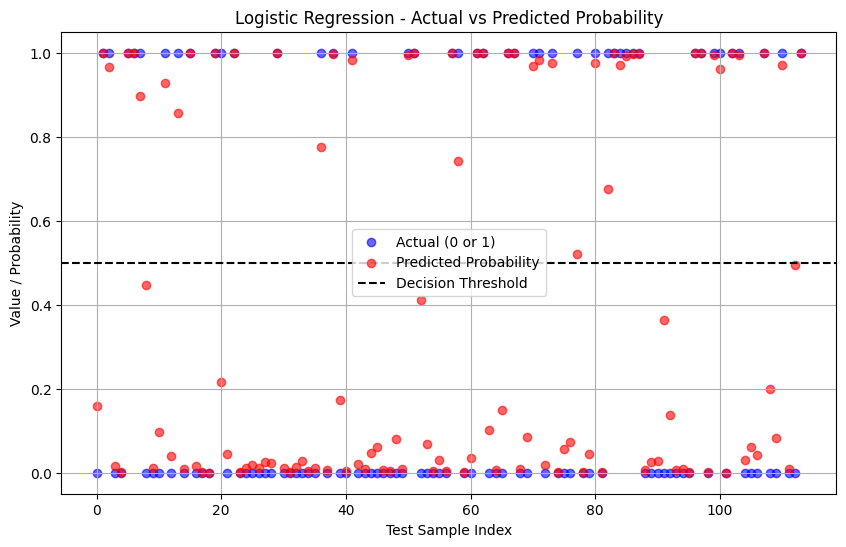

In [19]:
plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_test)), y_test, c='blue', label='Actual (0 or 1)', alpha=0.6)
plt.scatter(range(len(y_test)), y_pred_prob, c='red', label='Predicted Probability', alpha=0.6)
plt.axhline(y=0.5, color='black', linestyle='--', label='Decision Threshold')
plt.xlabel('Test Sample Index')
plt.ylabel('Value / Probability')
plt.title('Logistic Regression - Actual vs Predicted Probability')
plt.legend()
plt.grid(True)
plt.show()